In [17]:
import warnings; warnings.filterwarnings("ignore")
import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, roc_curve, f1_score,
    precision_score, recall_score, accuracy_score, confusion_matrix,
    ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE
import xgboost as xgb, lightgbm as lgb, shap

In [18]:
SEED = 42;  np.random.seed(SEED)
OUT  = "thesis_outputs";  os.makedirs(OUT, exist_ok=True)
plt.rcParams.update({"figure.dpi": 130, "font.size": 11})
sns.set_style("whitegrid")
 
def save(name):
    plt.savefig(f"{OUT}/{name}", bbox_inches="tight")
    print(f"  saved → {OUT}/{name}")
 
print("=" * 55)
print("  XAI for SME Risk — Pipeline")
print("=" * 55)

  XAI for SME Risk — Pipeline


In [19]:
print("\n[1/6] Loading datasets...")
p       = fetch_ucirepo(id=365)
X_p     = p.data.features
y_p     = p.data.targets.squeeze().astype(int)
print(f"  Polish  → {X_p.shape} | Bankrupt: {y_p.sum()} ({y_p.mean()*100:.1f}%)")


[1/6] Loading datasets...
  Polish  → (43405, 65) | Bankrupt: 2091 (4.8%)


In [20]:
try:
    df      = pd.read_csv("credit_risk_dataset.csv")
    X_c     = pd.get_dummies(df.drop("loan_status", axis=1), drop_first=True)
    y_c     = df["loan_status"].astype(int)
    print(f"  Credit  → {X_c.shape} | Default: {y_c.sum()} ({y_c.mean()*100:.1f}%)")
except FileNotFoundError:
    print("  ⚠  credit_risk_dataset.csv not found — using synthetic data")
    n = 5000;  np.random.seed(SEED)
    X_c = pd.DataFrame({
        "loan_amnt": np.random.randint(1000,40000,n).astype(float),
        "int_rate" : np.random.uniform(5,30,n),
        "annual_inc": np.random.randint(20000,150000,n).astype(float),
        "dti"      : np.random.uniform(0,40,n),
        "delinq_2yrs": np.random.randint(0,5,n).astype(float),
        "open_acc" : np.random.randint(1,30,n).astype(float),
        "revol_util": np.random.uniform(0,100,n),
        "total_acc" : np.random.randint(5,60,n).astype(float),
        "emp_length": np.random.randint(0,10,n).astype(float),
        "home_own"  : np.random.randint(0,3,n).astype(float),
    })
    y_c = ((X_c["dti"]>20).astype(int)|(X_c["int_rate"]>20).astype(int)).clip(0,1)
    print(f"  Credit  → {X_c.shape} | Default: {y_c.sum()} ({y_c.mean()*100:.1f}%)")

  ⚠  credit_risk_dataset.csv not found — using synthetic data
  Credit  → (5000, 10) | Default: 3430 (68.6%)



[2/6] EDA...
  saved → thesis_outputs/eda_01_class_distribution.png


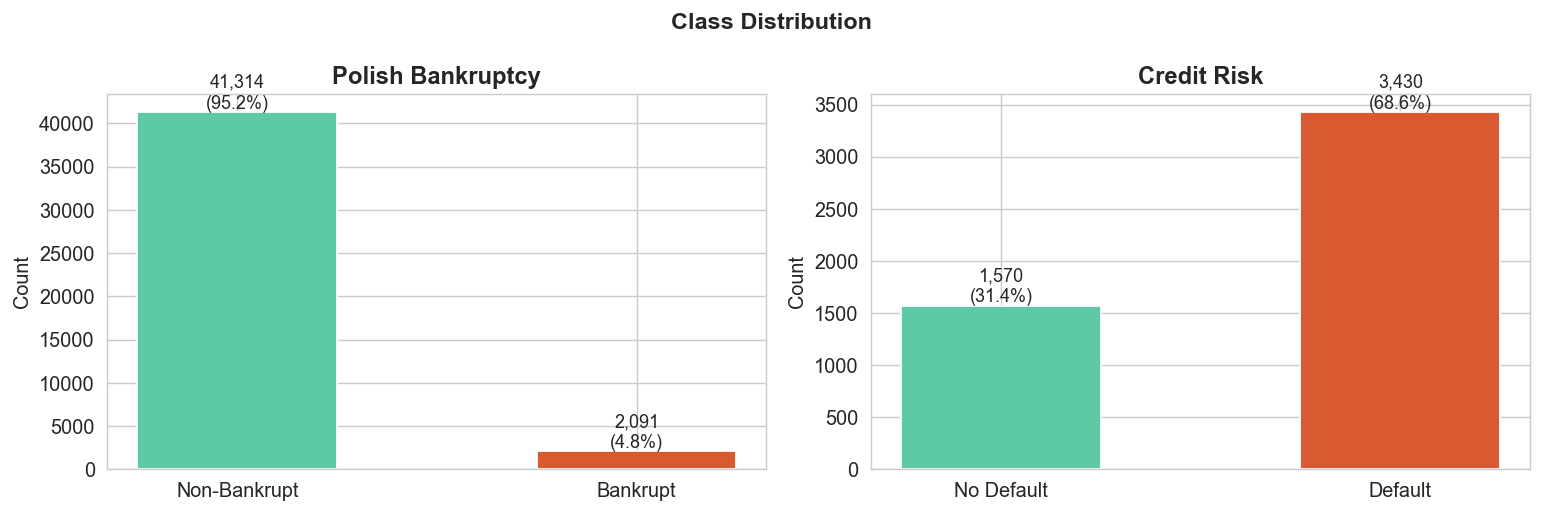

  saved → thesis_outputs/eda_02_missing_values.png


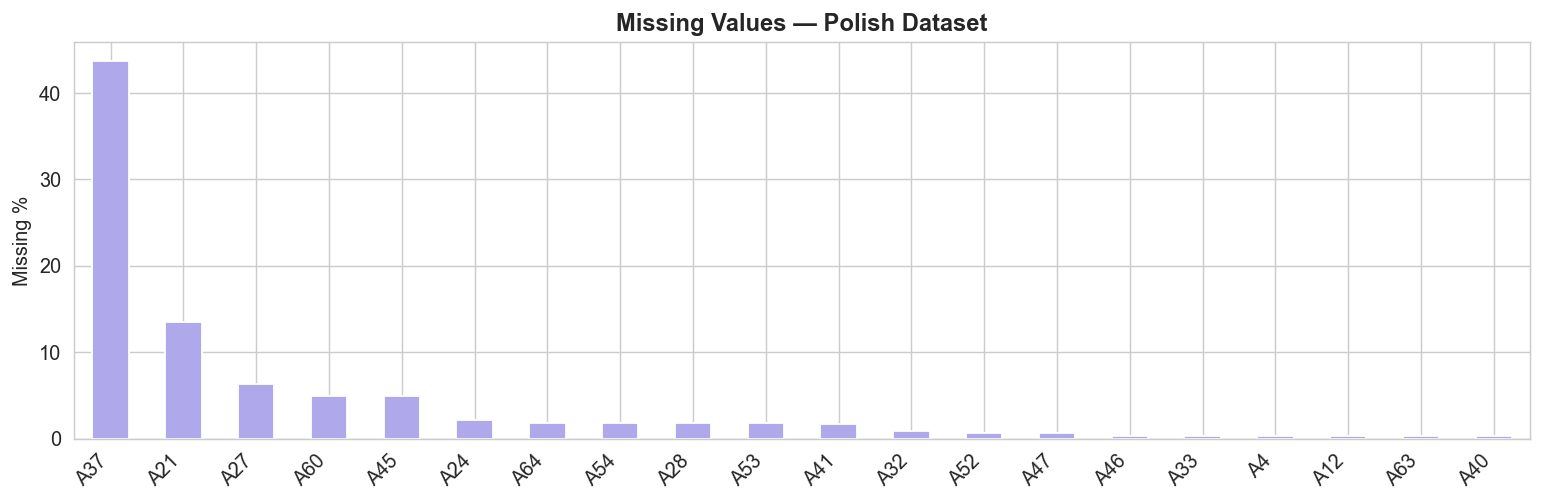

In [21]:
# 2. EDA
# ============================================================
print("\n[2/6] EDA...")
 
# Class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (y, lbls, title) in zip(axes, [
    (y_p, ["Non-Bankrupt","Bankrupt"], "Polish Bankruptcy"),
    (y_c, ["No Default","Default"],    "Credit Risk"),
]):
    counts = pd.Series(y).value_counts().sort_index()
    ax.bar(lbls, counts.values, color=["#5DCAA5","#D85A30"], edgecolor="white", width=0.5)
    ax.set_title(title, fontweight="bold");  ax.set_ylabel("Count")
    [ax.text(i, v+max(counts)*0.01, f"{v:,}\n({v/len(y)*100:.1f}%)",
             ha="center", fontsize=10) for i,v in enumerate(counts.values)]
plt.suptitle("Class Distribution", fontsize=13, fontweight="bold")
plt.tight_layout();  save("eda_01_class_distribution.png");  plt.show()
 
# Missing values (Polish)
miss = (X_p.isnull().mean()*100).sort_values(ascending=False).head(20)
miss[miss>0].plot(kind="bar", figsize=(12,4), color="#AFA9EC", edgecolor="white")
plt.title("Missing Values — Polish Dataset", fontweight="bold")
plt.ylabel("Missing %");  plt.xticks(rotation=45, ha="right")
plt.tight_layout();  save("eda_02_missing_values.png");  plt.show()

  saved → thesis_outputs/eda_04_correlation.png


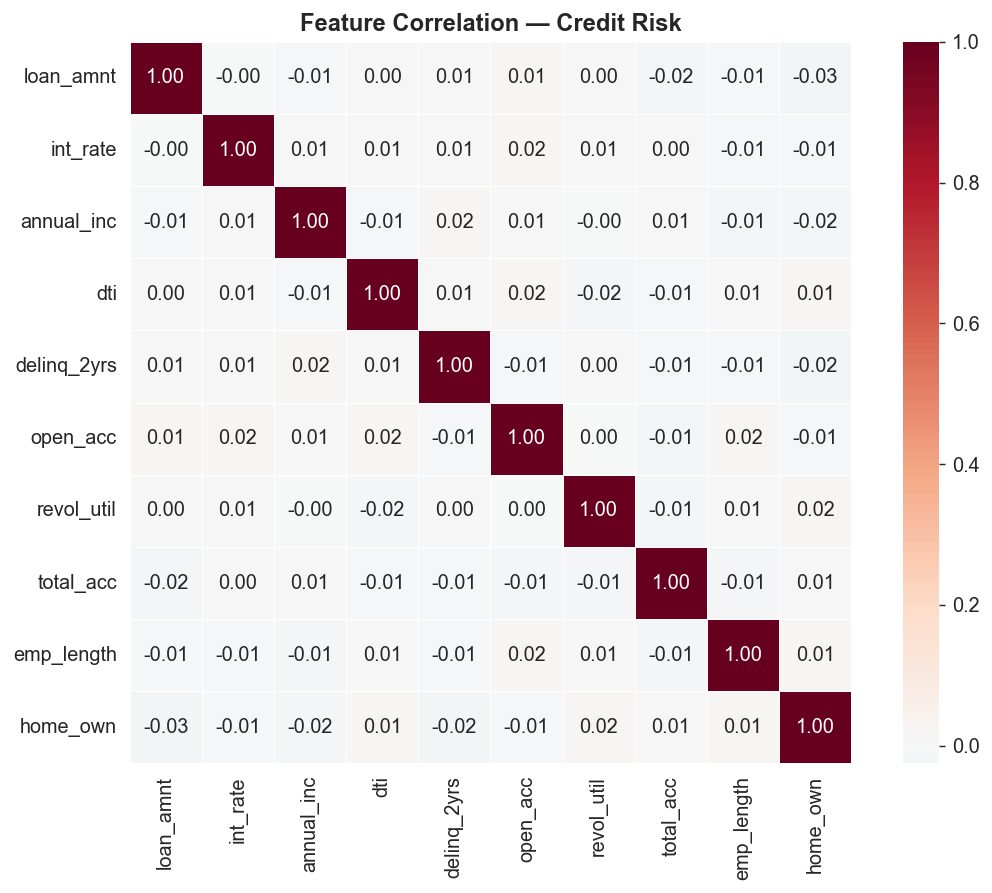

In [22]:
# Correlation heatmap (Credit Risk)
corr = X_c.select_dtypes(include=[np.number]).iloc[:,:10].corr()
plt.figure(figsize=(9,7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, linewidths=0.5, square=True)
plt.title("Feature Correlation — Credit Risk", fontweight="bold")
plt.tight_layout();  save("eda_04_correlation.png");  plt.show()


In [23]:
# 3. PREPROCESSING  (no data leakage)
# ============================================================
print("\n[3/6] Preprocessing...")
 
def preprocess(X, y, name=""):
    Xtr,Xte,ytr,yte = train_test_split(X, y, test_size=0.2,
                                        random_state=SEED, stratify=y)
    imp  = SimpleImputer(strategy="median")
    Xtr  = pd.DataFrame(imp.fit_transform(Xtr),  columns=X.columns)
    Xte  = pd.DataFrame(imp.transform(Xte),      columns=X.columns)
    sc   = StandardScaler()
    Xtr  = pd.DataFrame(sc.fit_transform(Xtr),   columns=X.columns)
    Xte  = pd.DataFrame(sc.transform(Xte),       columns=X.columns)
    Xtr, ytr = SMOTE(random_state=SEED).fit_resample(Xtr, ytr)
    print(f"  {name} → train: {Xtr.shape}  test: {Xte.shape}")
    return Xtr, Xte, pd.Series(ytr), yte
 
Xtr_p,Xte_p,ytr_p,yte_p = preprocess(X_p, y_p, "Polish")
Xtr_c,Xte_c,ytr_c,yte_c = preprocess(X_c, y_c, "Credit")


[3/6] Preprocessing...
  Polish → train: (66102, 65)  test: (8681, 65)
  Credit → train: (5488, 10)  test: (1000, 10)


In [24]:
 #4. MODEL TRAINING & EVALUATION
# ============================================================
print("\n[4/6] Training models...")
 
MODELS = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=SEED),
    "Random Forest"      : RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1),
    "XGBoost"            : xgb.XGBClassifier(n_estimators=200, max_depth=5,
                               learning_rate=0.05, eval_metric="logloss",
                               random_state=SEED, n_jobs=-1),
    "LightGBM"           : lgb.LGBMClassifier(n_estimators=200, max_depth=5,
                               learning_rate=0.05, random_state=SEED,
                               n_jobs=-1, verbose=-1),
}
 
def evaluate(models, Xtr, Xte, ytr, yte, name):
    results, fitted = {}, {}
    print(f"\n  ── {name} ──")
    print(f"  {'Model':<22} {'AUC':>6} {'F1':>6} {'Acc':>6} {'Prec':>6} {'Rec':>6}")
    print(f"  {'-'*54}")
    for n, m in models.items():
        m.fit(Xtr, ytr)
        yp  = m.predict(Xte)
        ypr = m.predict_proba(Xte)[:,1]
        results[n] = {
            "AUC"      : round(roc_auc_score(yte, ypr), 4),
            "F1"       : round(f1_score(yte, yp, zero_division=0), 4),
            "Accuracy" : round(accuracy_score(yte, yp), 4),
            "Precision": round(precision_score(yte, yp, zero_division=0), 4),
            "Recall"   : round(recall_score(yte, yp, zero_division=0), 4),
        }
        fitted[n] = m
        r = results[n]
        print(f"  {n:<22} {r['AUC']:>6.3f} {r['F1']:>6.3f} {r['Accuracy']:>6.3f} "
              f"{r['Precision']:>6.3f} {r['Recall']:>6.3f}")
    return results, fitted
 
res_p, fit_p = evaluate(MODELS, Xtr_p, Xte_p, ytr_p, yte_p, "Polish Bankruptcy")
res_c, fit_c = evaluate(MODELS, Xtr_c, Xte_c, ytr_c, yte_c, "Credit Risk")


[4/6] Training models...

  ── Polish Bankruptcy ──
  Model                     AUC     F1    Acc   Prec    Rec
  ------------------------------------------------------
  Logistic Regression     0.728  0.174  0.722  0.101  0.608
  Random Forest           0.928  0.539  0.956  0.548  0.531
  XGBoost                 0.950  0.532  0.936  0.410  0.758
  LightGBM                0.947  0.512  0.932  0.392  0.739

  ── Credit Risk ──
  Model                     AUC     F1    Acc   Prec    Rec
  ------------------------------------------------------
  Logistic Regression     0.963  0.908  0.877  0.936  0.880
  Random Forest           1.000  0.999  0.998  0.997  1.000
  XGBoost                 1.000  0.999  0.998  0.997  1.000
  LightGBM                1.000  0.999  0.998  0.997  1.000


In [28]:
def preprocess(X, y, name=""):
    # Step 1: Split first (no leakage)
    Xtr, Xte, ytr, yte = train_test_split(
        X, y, test_size=0.2, random_state=SEED, stratify=y
    )

    # Step 2: Impute — fit on train only
    imp = SimpleImputer(strategy="median")
    Xtr = pd.DataFrame(imp.fit_transform(Xtr), columns=X.columns)
    Xte = pd.DataFrame(imp.transform(Xte),     columns=X.columns)

    # Step 3: Scale — fit on train only
    sc  = StandardScaler()
    Xtr = pd.DataFrame(sc.fit_transform(Xtr),  columns=X.columns)
    Xte = pd.DataFrame(sc.transform(Xte),      columns=X.columns)

    # Step 4: SMOTE — train only, then RESTORE column names
    sm = SMOTE(random_state=SEED)
    Xtr_arr, ytr_arr = sm.fit_resample(Xtr, ytr)
    Xtr = pd.DataFrame(Xtr_arr, columns=X.columns)  # ← this line is the fix
    ytr = pd.Series(ytr_arr)

    print(f"  {name} → train: {Xtr.shape}  test: {Xte.shape}")
    return Xtr, Xte, ytr, yte